[![Labellerr](https://storage.googleapis.com/labellerr-cdn/%200%20Labellerr%20template/notebook.webp)](https://www.labellerr.com)

# **Automated Dental Cavity Detection**

---

[![labellerr](https://img.shields.io/badge/Labellerr-BLOG-black.svg)](https://www.labellerr.com/blog/<BLOG_NAME>)
[![Youtube](https://img.shields.io/badge/Labellerr-YouTube-b31b1b.svg)](https://www.youtube.com/@Labellerr)
[![Github](https://img.shields.io/badge/Labellerr-GitHub-green.svg)](https://github.com/Labellerr/Hands-On-Learning-in-Computer-Vision)

## Overview

This notebook demonstrates an **end-to-end computer vision pipeline** for **Automated Dental Cavity Detection** using **video**. The workflow utilizes a **fine-tuned YOLOv11 model** to precisely detect cavities in dental imaging.

---

## Real-World Applications

**Dental Diagnostics**  
Automated tracking to detect cavities early by monitoring dental videos and imagery.

**Clinical Workflow Analysis**  
Assisting dentists by automatically highlighting potential cavity regions during a visual examination.

**Automated Patient Records**  
Real-time tracking of dental issues to ensure all required treatments are documented before a procedure begins.

**Dental Skill Assessment**  
Analyzing how effectively dental trainees can identify and examine cavities in patients.

---

## Key Technical Features

**High-Definition Detection**  
Utilization of precise bounding boxes to ensure accurate boundaries on dental cavities.

**Real-Time Processing**  
Strategic use of the **YOLOv11** architecture to maintain incredibly high inference speeds on video without sacrificing precision.

**High Precision Classification**  
Achieved high precision across complex classes of visually similar dental conditions.

---

## Annotate your Custom dataset using Labellerr

 ***1. Visit the [Labellerr](https://www.labellerr.com/?utm_source=githubY&utm_medium=social&utm_campaign=github_clicks) website and click **“Sign Up”**.*** 

 ***2. After signing in, create your workspace by entering a unique name.***

 ***3. Navigate to your workspace’s API keys page (e.g., `https://<your-workspace>.labellerr.com/workspace/api-keys`) to generate your **API Key** and **API Secret**.***

 ***4. Store the credentials securely, and then use them to initialise the SDK or API client with `api_key`, `api_secret`.***


---


## Install Dependencies
Install the Ultralytics YOLO package along with necessary computer vision libraries like OpenCV and Matplotlib.


In [1]:
!pip install ultralytics opencv-python matplotlib cv2

ERROR: Could not find a version that satisfies the requirement cv2 (from versions: none)

[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: C:\Python313\python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for cv2


## Setup Utilities
We start by cloning a utility repository that provides helper scripts for extracting frames from video and converting dataset formats.


In [2]:
!git clone https://github.com/Labellerr/yolo_finetune_utils.git

Cloning into 'yolo_finetune_utils'...


## Data Preparation: Frame Extraction
To create our training dataset, we extract random frames from our dental video.


In [ ]:
from yolo_finetune_utils.frame_extractor import extract_random_frames

extract_random_frames(
    paths=['download (11).mp4'],
    total_images=100,
    out_dir="dataset_frames",
    jpg_quality=100,
    seed=42
)

[✓] Extracted 7 frames to folder: dataset_frames


## Format Conversion (COCO to YOLO)
The extracted frames were labeled and exported in COCO JSON format. YOLO requires a specific folder structure (`images/train`, `labels/train`, etc.). We use the `coco_to_yolo_converter` to parse the JSON and split our data into training and validation sets.


In [10]:
from yolo_finetune_utils.coco_yolo_converter.bbox_converter import coco_to_yolo_converter

coco_to_yolo_converter(
    json_path="59cdf541-a337-4657-900c-e22b51a10c1c.json",
    images_dir="dataset_frames",
    output_dir="yoloDataset",
    use_split=True,
    train_ratio=0.7,
    val_ratio=0.2,
    test_ratio=0.1,
    verbose=True
)


Loading COCO dataset from 59cdf541-a337-4657-900c-e22b51a10c1c.json
Found 7 images and 42 annotations
Categories mapping:
  COCO ID 0 (cavity) -> YOLO class 0
Images with annotations: 7
Dataset split:
  train: 4 images
  val: 1 images
  test: 2 images

Processing train split...

Processing val split...

Processing test split...

Conversion completed:
  Successfully processed: 7 images
  Failed to find: 0 images
  Total annotations converted: 42
  Categories: 1

YOLO dataset created at: yoloDataset
Dataset configuration: yoloDataset\dataset.yaml


{'output_path': 'yoloDataset',
 'yaml_path': 'yoloDataset\\dataset.yaml',
 'stats': {'total_images': 7,
  'images_with_annotations': 7,
  'successful_copies': 7,
  'failed_copies': 0,
  'total_annotations': 42,
  'categories': 1,
  'category_mapping': {0: 0},
  'class_names': {0: 'cavity'}}}

# Load and Train YOLO Model

Loads the YOLO object detection model and trains it using the converted YOLO dataset.
- Data: Path to YOLO-style `dataset.yaml`
- Parameters: epochs, image size, batch size, device, dataloader workers, experiment name.


In [11]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt") 

model.train(
    data="yoloDataset\dataset.yaml",
    epochs=150,        # Still need this to train long enough
    freeze=10,         # Still critical to protect pre-trained weights
    imgsz=640,
    patience=50,
    # Kept to prevent memorizing the background:
    mosaic=1.0,      
    hsv_h=0.015,     # Helps if lighting flickers in the video
    
    # Removed because you are testing on the exact same static video:
    mixup=0.0,
    degrees=0.0,    
    flipud=0.0,      
    fliplr=0.0,      
    scale=0.0        
)

New https://pypi.org/project/ultralytics/8.4.144 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.33  Python-3.10.9 torch-2.11.0+cpu CPU (12th Gen Intel Core(TM) i5-1235U)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=yoloDataset\dataset.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x00000237A71713C0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.0480

## Run Inference on a Single Frame with Custom Confidence
We can adjust the confidence threshold to see how it affects the detection of the cavity.



0: 384x640 6 cavitys, 73.7ms
Speed: 3.2ms preprocess, 73.7ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)


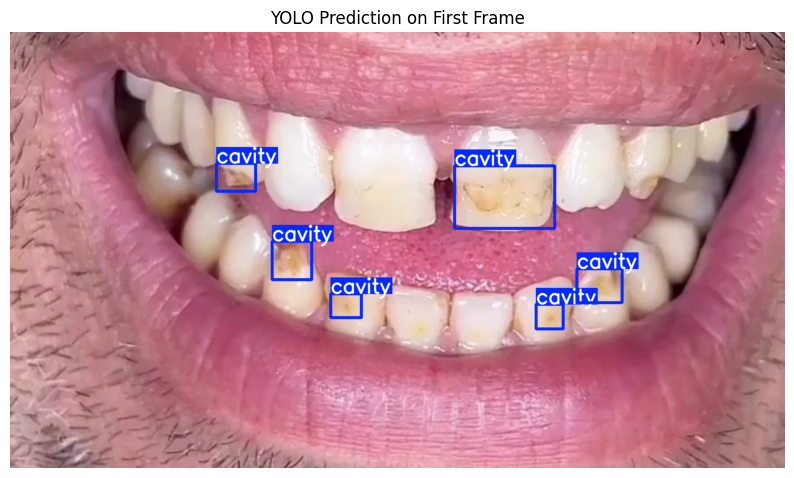

In [21]:
%matplotlib inline
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

# 1. Load the fine-tuned YOLO model
model = YOLO('runs/detect/train/weights/best.pt')

# 2. Open the video file
video_path = 'download (11).mp4' 
cap = cv2.VideoCapture(video_path)

# 3. Read the first frame
ret, frame = cap.read()

if ret:
    # 4. Run YOLO inference on the first frame
    results = model(frame, conf=0.05)  # Set confidence threshold here
    
    # 5. Plot the predictions on the frame
    res_plotted = results[0].plot(conf=False)
    
    # 6. OpenCV uses BGR, but matplotlib uses RGB. Convert the color space for display.
    res_rgb = cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB)
    
    # 7. Display the result in the notebook output
    plt.figure(figsize=(10, 8))
    plt.imshow(res_rgb)
    plt.axis('off')
    plt.title('YOLO Prediction on First Frame')
    plt.show()
else:
    print("Error: Could not read a frame from the video.")

# 8. Release the video capture object
cap.release()


## Run Inference on Video
Finally, we load our best trained weights and run inference back on the original dental video. 

We lower the confidence threshold slightly (`conf=0.5`) to account for the small dataset, and we remove confidence percentages for cleaner outputs.


In [ ]:
from ultralytics import YOLO

# 1. Load your best trained model for dental cavities
model = YOLO('runs/detect/train/weights/best.pt')

# 2. Use the local dental video for inference
video_path = 'download (11).mp4'

# 3. Run inference with confidence score UI elements removed
results = model.predict(
    source=video_path,
    save=True,
    conf=0.5,
    imgsz=640,
    show_boxes=True,   # Keeps the bounding boxes
    show_conf=False,   # Removes the confidence percentages (0.85, etc.)
    show_labels=True,  # Keeps only the names (cavity)
    project='runs/detect',
    name='dental_cavity_output'
)

print("✅ Dental Cavity inference complete. Video saved.")



WARNING 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/340) d:\Desktop\Desk\Labellerr Github Projects\Use_Case_Projects\dental teeth\download (11).mp4: 384x640 6 cavitys, 89.4ms
video 1/1 (frame 2/340) d:\Desktop\Desk\Labellerr Github Projects\Use_Case_Projects\dental teeth\download (11).mp4: 384x640 6 cavitys, 89.1ms
video 1/1 (frame 3/340) d:\Desktop\Desk\Labellerr Github Projects\Use_Case_Projects\dental teeth\download (11).mp4: 384x640 6 cavitys, 82.8ms
video 1/1 (frame 4/340) d:\Desktop\

---

## 👨‍💻 About Labellerr's Hands-On Learning in Computer Vision

Thank you for exploring this **Labellerr Hands-On Computer Vision Cookbook**! We hope this notebook helped you learn, prototype, and accelerate your vision projects.  
Labellerr provides ready-to-run Jupyter/Colab notebooks for the latest models and real-world use cases in computer vision, AI agents, and data annotation.

---
## 🧑‍🔬 Check Our Popular Youtube Videos

Whether you're a beginner or a practitioner, our hands-on training videos are perfect for learning custom model building, computer vision techniques, and applied AI:

- [How to Fine-Tune YOLO on Custom Dataset](https://www.youtube.com/watch?v=pBLWOe01QXU)  
  Step-by-step guide to fine-tuning YOLO for real-world use—environment setup, annotation, training, validation, and inference.
- [Build a Real-Time Intrusion Detection System with YOLO](https://www.youtube.com/watch?v=kwQeokYDVcE)  
  Create an AI-powered system to detect intruders in real time using YOLO and computer vision.
- [Finding Athlete Speed Using YOLO](https://www.youtube.com/watch?v=txW0CQe_pw0)  
  Estimate real-time speed of athletes for sports analytics.
- [Object Counting Using AI](https://www.youtube.com/watch?v=smsjBBQcIUQ)  
  Learn dataset curation, annotation, and training for robust object counting AI applications.
---

## 🎦 Popular Labellerr YouTube Videos

Level up your skills and see video walkthroughs of these tools and notebooks on the  
[Labellerr YouTube Channel](https://www.youtube.com/@Labellerr/videos):

- [How I Fixed My Biggest Annotation Nightmare with Labellerr](https://www.youtube.com/watch?v=hlcFdiuz_HI) – Solving complex annotation for ML engineers.
- [Explore Your Dataset with Labellerr's AI](https://www.youtube.com/watch?v=LdbRXYWVyN0) – Auto-tagging, object counting, image descriptions, and dataset exploration.
- [Boost AI Image Annotation 10X with Labellerr's CLIP Mode](https://www.youtube.com/watch?v=pY_o4EvYMz8) – Refine annotations with precision using CLIP mode.
- [Boost Data Annotation Accuracy and Efficiency with Active Learning](https://www.youtube.com/watch?v=lAYu-ewIhTE) – Speed up your annotation workflow using Active Learning.

> 👉 **Subscribe** for Labellerr's deep learning, annotation, and AI tutorials, or watch videos directly alongside notebooks!

---

## 🤝 Stay Connected

- **Website:** [https://www.labellerr.com/](https://www.labellerr.com/)
- **Blog:** [https://www.labellerr.com/blog/](https://www.labellerr.com/blog/)
- **GitHub:** [Labellerr/Hands-On-Learning-in-Computer-Vision](https://github.com/Labellerr/Hands-On-Learning-in-Computer-Vision)
- **LinkedIn:** [Labellerr](https://in.linkedin.com/company/labellerr)
- **Twitter/X:** [@Labellerr1](https://x.com/Labellerr1)

*Happy learning and building with Labellerr!*
